<a href="https://colab.research.google.com/github/Arjun-08/Adaptive-High-Boost-Image-Sharpening/blob/main/Image_Sharpening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The sharpened image is given by:

𝑔
(
𝑚
,
𝑛
)
=
𝑓
(
𝑚
,
𝑛
)
+
𝑘
(
𝑚
,
𝑛
)
⋅
[
𝑓
(
𝑚
,
𝑛
)
∗
ℎ
(
𝑚
,
𝑛
)
]
g(m,n)=f(m,n)+k(m,n)⋅[f(m,n)∗h(m,n)]
where:

𝑓
(
𝑚
,
𝑛
)
f(m,n) is the original image.
ℎ
(
𝑚
,
𝑛
)

h(m,n) is the high-pass filter (Laplacian filter in this case).
∗
∗ denotes convolution.
𝑘
(
𝑚
,
𝑛
)
k(m,n) is a spatially varying gain, which depends on the magnitude of the high-pass filter output.

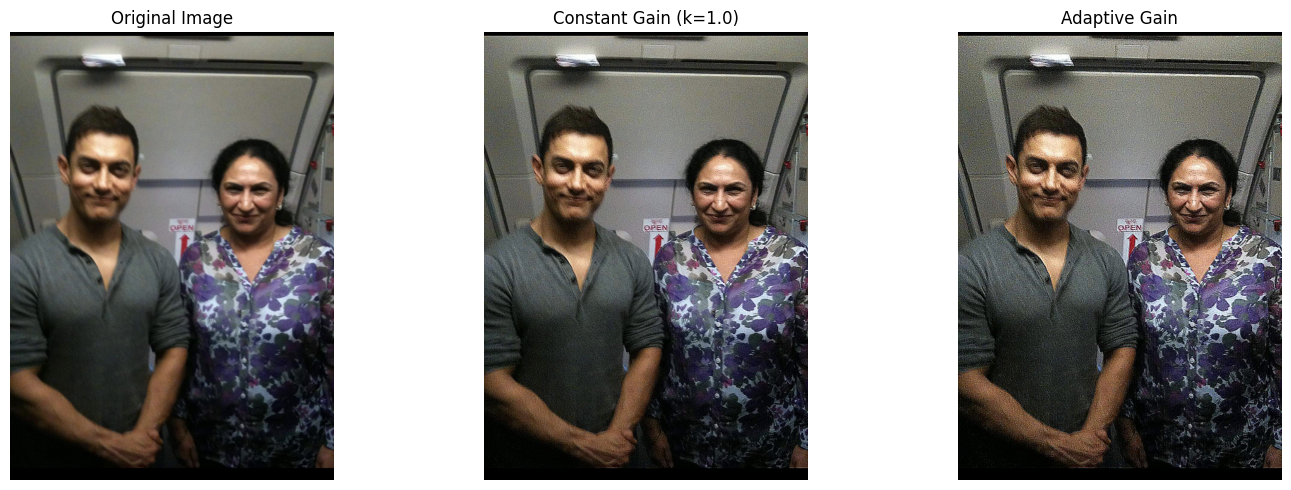

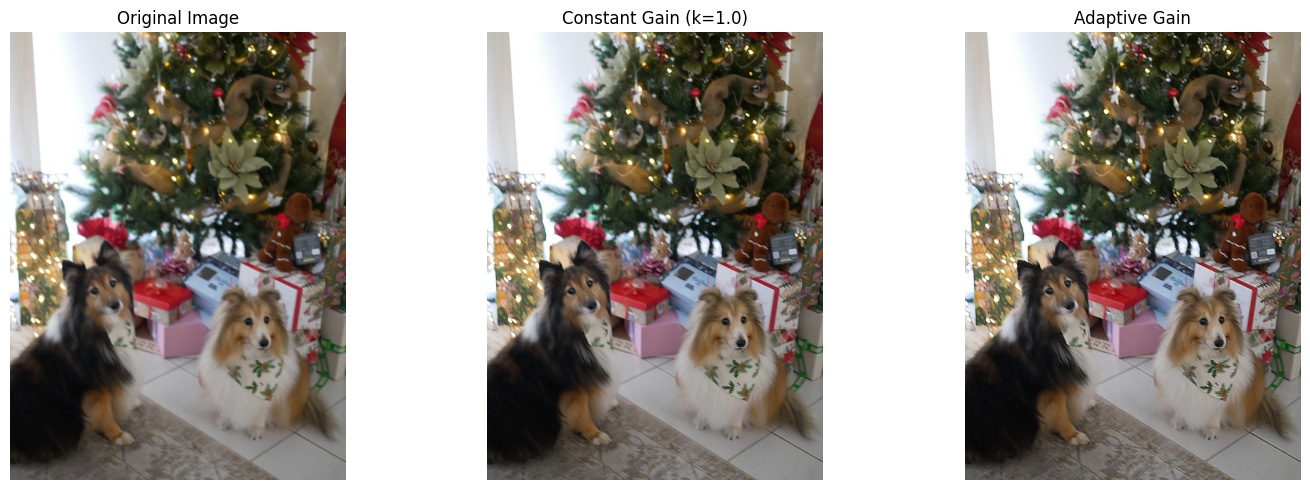

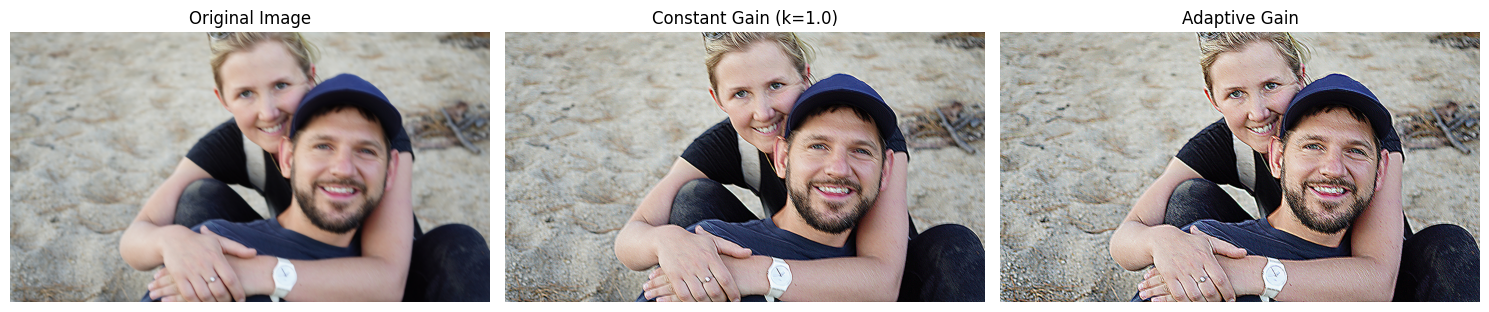

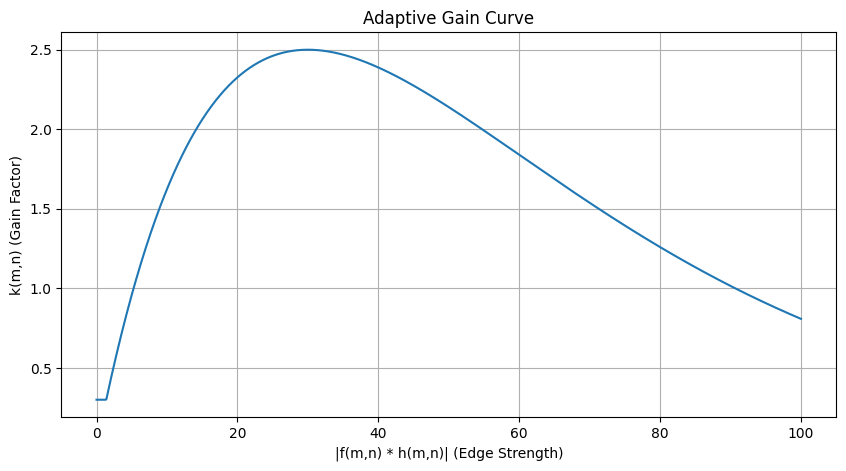

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import cv2

def load_image(image_path):
    """Load image from path and convert to RGB."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")
    return img

def apply_high_pass_filter(image, h_filter):
    """Apply high pass filter to each channel of the image."""
    if len(image.shape) == 3:
        return np.stack([convolve2d(image[:,:,i], h_filter, mode='same', boundary='symm')
                        for i in range(3)], axis=2)
    return convolve2d(image, h_filter, mode='same', boundary='symm')

def adaptive_gain(filter_output, k_max=2.5, peak_point=30, width=20):
    """
    Calculate spatially varying gain based on filter output magnitude.
    Uses a modified Gaussian function to create a peak-shaped curve.

    Args:
        filter_output: High-pass filter output
        k_max: Maximum gain value
        peak_point: Location of maximum gain
        width: Controls the width of the curve
    """
    magnitude = np.abs(filter_output)

    # Create a curve that rises and then falls
    k = k_max * (magnitude/peak_point) * np.exp(1 - magnitude/peak_point)

    # Ensure minimum gain isn't too small
    k = np.maximum(k, 0.3)

    return k

def high_boost_filter(image, h_filter, k, adaptive=False):
    """
    Apply high boost filtering to the image.

    Args:
        image: Input image (uint8)
        h_filter: High pass filter kernel
        k: Gain factor (constant) or maximum gain (for adaptive)
        adaptive: Whether to use adaptive gain

    Returns:
        Sharpened image (uint8)
    """
    # Convert to float for processing
    image_float = image.astype(float)

    # Apply high pass filter
    filter_output = apply_high_pass_filter(image_float, h_filter)

    # Calculate gain factor
    if adaptive:
        gain = adaptive_gain(filter_output)
    else:
        gain = k

    # Apply high boost filtering
    sharpened = image_float + gain * filter_output

    # Saturate values
    sharpened = np.clip(sharpened, 0, 255)

    return sharpened.astype(np.uint8)

def plot_gain_curve():
    """Plot the adaptive gain curve."""
    x = np.linspace(0, 100, 1000)
    y = adaptive_gain(x)

    plt.figure(figsize=(10, 5))
    plt.plot(x, y)
    plt.title('Adaptive Gain Curve')
    plt.xlabel('|f(m,n) * h(m,n)| (Edge Strength)')
    plt.ylabel('k(m,n) (Gain Factor)')
    plt.grid(True)
    plt.show()

def process_images(image_paths):
    """Process multiple images with both constant and adaptive gain."""
    # Define the Laplacian filter
    h = np.array([[-1, -1, -1],
                 [-1,  8, -1],
                 [-1, -1, -1]])

    # Process each image
    for i, path in enumerate(image_paths):
        # Load image
        img = load_image(path)

        # Apply both constant and adaptive filtering
        sharpened_constant = high_boost_filter(img, h, k=1.0, adaptive=False)
        sharpened_adaptive = high_boost_filter(img, h, k=2.5, adaptive=True)

        # Display results
        plt.figure(figsize=(15, 5))

        plt.subplot(131)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(132)
        plt.imshow(cv2.cvtColor(sharpened_constant, cv2.COLOR_BGR2RGB))
        plt.title('Constant Gain (k=1.0)')
        plt.axis('off')

        plt.subplot(133)
        plt.imshow(cv2.cvtColor(sharpened_adaptive, cv2.COLOR_BGR2RGB))
        plt.title('Adaptive Gain')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# Example usage:
image_paths = ['/content/FiljQr_XwAEB1qA.jpeg',
              '/content/FlA4ZjaagAANx_f.jpeg',
              '/content/Photo_Unblur_Before_KpGfyYx.max-1000x1000.png']
process_images(image_paths)
plot_gain_curve()